In [2]:
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import rdMolTransforms
from rdkit.Chem.Draw import rdMolDraw2D, rdDepictor, IPythonConsole
rdDepictor.SetPreferCoordGen(True)
from IPython.display import Image

# smiles = data["smiles"][5:6].values
smiles = ['CN1C=NC2=C1C(=O)N(C(=O)N2C)C']

# 3D for lengths
mol3d = Chem.AddHs(Chem.MolFromSmiles(smiles[0]))
Chem.EmbedMolecule(mol3d, randomSeed=42)
Chem.MMFFOptimizeMolecule(mol3d)

bonds = [(x.GetBeginAtomIdx(), x.GetEndAtomIdx()) for x in mol3d.GetBonds()]

conf = mol3d.GetConformer()

b_lengths = []
b_angles = []

for b in bonds:
    bl = rdMolTransforms.GetBondLength(conf,b[0],b[1]) #GetAngleDeg
    b_lengths.append(str(round(bl,2)))


print(len(b_lengths))
print(b_lengths)
print(len(bonds))
print(bonds)

25
['1.44', '1.37', '1.32', '1.36', '1.36', '1.42', '1.23', '1.4', '1.41', '1.23', '1.4', '1.45', '1.45', '1.37', '1.37', '1.09', '1.09', '1.09', '1.08', '1.09', '1.09', '1.09', '1.09', '1.09', '1.09']
25
[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (6, 8), (8, 9), (9, 10), (9, 11), (11, 12), (8, 13), (5, 1), (11, 4), (0, 14), (0, 15), (0, 16), (2, 17), (12, 18), (12, 19), (12, 20), (13, 21), (13, 22), (13, 23)]


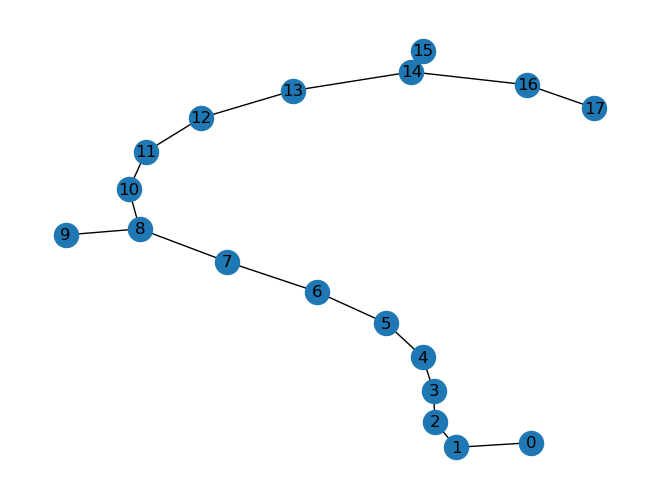

In [15]:
from rdkit import Chem
import networkx as nx
from rdkit.Chem import Draw

smiles = '*CCCCCCNC(=O)CCCCC(=O)N*'
mol = Chem.MolFromSmiles(smiles)
img = Draw.MolToImage(mol)

#img.show()

# Get adjacency matrix
adjacency_matrix = Chem.GetAdjacencyMatrix(mol, useBO = True)

# Convert adjacency matrix to NetworkX graph
G = nx.from_numpy_array(adjacency_matrix)

# Add nodes to the graph
num_atoms = mol.GetNumAtoms()
G.add_nodes_from(range(num_atoms))

# Add edges to the graph based on the adjacency matrix
for i in range(num_atoms):
    for j in range(i + 1, num_atoms):
        if adjacency_matrix[i, j] != 0:
            G.add_edge(i, j, weight=adjacency_matrix[i, j])  # Add edge with bond order as weight

# Optionally, visualize the graph
nx.draw(G, with_labels=True)

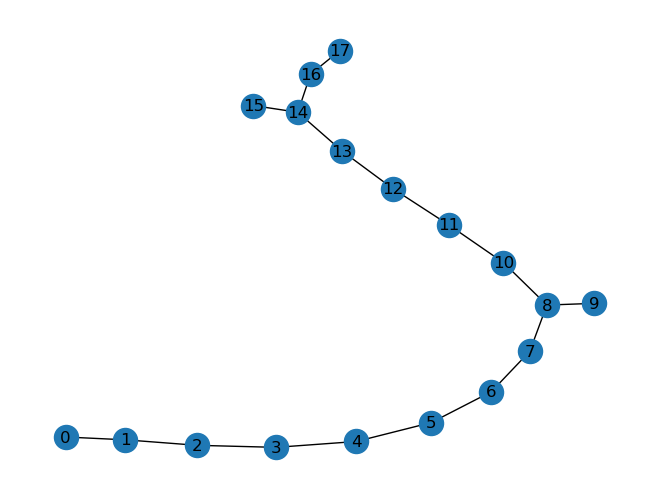

In [20]:
from rdkit import Chem
import networkx as nx
from rdkit.Chem import Draw

smiles = '*CCCCCCNC(=O)CCCCC(=O)N*'
mol = Chem.MolFromSmiles(smiles)
img = Draw.MolToImage(mol)

#img.show()

# Get adjacency matrix
adjacency_matrix = Chem.GetAdjacencyMatrix(mol, useBO = True)

# Convert adjacency matrix to NetworkX graph
G = nx.from_numpy_array(adjacency_matrix)


nx.draw(G, with_labels=True)